# Create_Submissions_2

In [2]:
import os

# Move up one level to set the working directory to the repo root
os.chdir(os.path.abspath(os.path.join(os.getcwd(), "..")))

## Setup

In [3]:
import pandas as pd
import numpy as np
from pathlib import Path

DEFAULT_COMPETITION_DATA_PATH = Path(os.path.abspath(os.path.join(os.getcwd(), r"data\kaggle")))
SUBMISSION_DATA_PATH = Path(os.path.abspath(os.path.join(os.getcwd(), r"data\submissions")))
DATA_PATH = Path(os.path.abspath(os.path.join(os.getcwd(), r"data\fivethirtyeight")))

## `Round1_538Ratings.csv`

In [4]:
# Load data files
sample_submission = pd.read_csv(DEFAULT_COMPETITION_DATA_PATH / "SampleSubmissionStage1.csv")
ratings_men = pd.read_csv(DATA_PATH / "538ratingsMen_2016-2023.csv")
ratings_women = pd.read_csv(DATA_PATH / "538ratingsWomen_2016-2023.csv")
results_men = pd.read_csv(DEFAULT_COMPETITION_DATA_PATH / "MNCAATourneyCompactResults.csv")
results_women = pd.read_csv(DEFAULT_COMPETITION_DATA_PATH / "WNCAATourneyCompactResults.csv")

# Parse Season, Team1, Team2 from ID in sample_submission
sample_submission[['Season', 'Team1', 'Team2']] = sample_submission['ID'].str.split('_', expand=True)
sample_submission['Season'] = sample_submission['Season'].astype(int)
sample_submission['Team1'] = sample_submission['Team1'].astype(int)
sample_submission['Team2'] = sample_submission['Team2'].astype(int)

# Filter 538 ratings to only include seasons 2021-2023
ratings_men = ratings_men[ratings_men['Season'] >= 2021]
ratings_women = ratings_women[ratings_women['Season'] >= 2021]

# Select necessary columns from ratings
ratings_men = ratings_men[['Season', 'TeamID', '538rating']].rename(columns={'538rating': 'Rating'})
ratings_women = ratings_women[['Season', 'TeamID', '538rating']].rename(columns={'538rating': 'Rating'})

# Fill missing ratings with the average of all 538 ratings
avg_men_rating = ratings_men['Rating'].mean()
avg_women_rating = ratings_women['Rating'].mean()

# Merge ratings for Team1 and Team2
m_submission = sample_submission[sample_submission['Team1'] < 3000].copy()  # Men's tournament
w_submission = sample_submission[sample_submission['Team1'] >= 3000].copy()  # Women's tournament

# Merge ratings for men's tournament
m_submission = m_submission.merge(ratings_men, left_on=['Season', 'Team1'], right_on=['Season', 'TeamID'], how='left') \
                           .rename(columns={'Rating': 'Team1_Rating'}).drop(columns=['TeamID'])

m_submission = m_submission.merge(ratings_men, left_on=['Season', 'Team2'], right_on=['Season', 'TeamID'], how='left') \
                           .rename(columns={'Rating': 'Team2_Rating'}).drop(columns=['TeamID'])

# Merge ratings for women's tournament
w_submission = w_submission.merge(ratings_women, left_on=['Season', 'Team1'], right_on=['Season', 'TeamID'], how='left') \
                           .rename(columns={'Rating': 'Team1_Rating'}).drop(columns=['TeamID'])

w_submission = w_submission.merge(ratings_women, left_on=['Season', 'Team2'], right_on=['Season', 'TeamID'], how='left') \
                           .rename(columns={'Rating': 'Team2_Rating'}).drop(columns=['TeamID'])

# Combine back men's and women's tournaments
submission_with_ratings = pd.concat([m_submission, w_submission])

# Ensure DataFrame index is reset
submission_with_ratings = submission_with_ratings.reset_index(drop=True)

# Replace NaN values in Team1_Rating
submission_with_ratings['Team1_Rating'] = np.where(
    submission_with_ratings['Team1_Rating'].isna() & (submission_with_ratings['Team1'] < 3000),
    avg_men_rating,
    np.where(submission_with_ratings['Team1_Rating'].isna(), avg_women_rating, submission_with_ratings['Team1_Rating'])
)

# Replace NaN values in Team2_Rating
submission_with_ratings['Team2_Rating'] = np.where(
    submission_with_ratings['Team2_Rating'].isna() & (submission_with_ratings['Team2'] < 3000),
    avg_men_rating,
    np.where(submission_with_ratings['Team2_Rating'].isna(), avg_women_rating, submission_with_ratings['Team2_Rating'])
)

# Assign the appropriate average rating based on tournament type
submission_with_ratings.loc[submission_with_ratings['Team1_Rating'].isna(), 'Team1_Rating'] = \
    submission_with_ratings['Team1'].apply(lambda x: avg_men_rating if x < 3000 else avg_women_rating)

submission_with_ratings.loc[submission_with_ratings['Team2_Rating'].isna(), 'Team2_Rating'] = \
    submission_with_ratings['Team2'].apply(lambda x: avg_men_rating if x < 3000 else avg_women_rating)

# Recompute features now that missing values have been filled
submission_with_ratings['RatingDiff'] = submission_with_ratings['Team1_Rating'] - submission_with_ratings['Team2_Rating']
submission_with_ratings['RatingRatio'] = submission_with_ratings['Team1_Rating'] / submission_with_ratings['Team2_Rating']
submission_with_ratings['LogRatingRatio'] = np.log(submission_with_ratings['Team1_Rating']) - np.log(submission_with_ratings['Team2_Rating'])

# Z-score normalization (by season)
season_mean_std = submission_with_ratings.groupby('Season')[['Team1_Rating', 'Team2_Rating']].agg(['mean', 'std'])
season_mean_std.columns = ['Team1_mean', 'Team1_std', 'Team2_mean', 'Team2_std']
submission_with_ratings = submission_with_ratings.merge(season_mean_std, on='Season', how='left')

submission_with_ratings['NormRating1'] = (submission_with_ratings['Team1_Rating'] - submission_with_ratings['Team1_mean']) / submission_with_ratings['Team1_std']
submission_with_ratings['NormRating2'] = (submission_with_ratings['Team2_Rating'] - submission_with_ratings['Team2_mean']) / submission_with_ratings['Team2_std']

# Win probability approximation
submission_with_ratings['WinProb_Team1'] = 1 / (1 + np.exp(-submission_with_ratings['RatingDiff']))
submission_with_ratings['WinProb_Team2'] = 1 - submission_with_ratings['WinProb_Team1']

# Average team rating
submission_with_ratings['AvgRating'] = (submission_with_ratings['Team1_Rating'] + submission_with_ratings['Team2_Rating']) / 2

# Upset potential score
submission_with_ratings['UpsetScore'] = np.exp(-submission_with_ratings['RatingDiff'])

# Merge with actual outcomes from tournament results
results_men = results_men[['Season', 'WTeamID', 'LTeamID']].copy()
results_men['Result'] = 1  # Team1 wins
results_men_rev = results_men.rename(columns={'WTeamID': 'LTeamID', 'LTeamID': 'WTeamID'})
results_men_rev['Result'] = 0  # Team1 loses
results_men = pd.concat([results_men, results_men_rev]).rename(columns={'WTeamID': 'Team1', 'LTeamID': 'Team2'})

results_women = results_women[['Season', 'WTeamID', 'LTeamID']].copy()
results_women['Result'] = 1
results_women_rev = results_women.rename(columns={'WTeamID': 'LTeamID', 'LTeamID': 'WTeamID'})
results_women_rev['Result'] = 0
results_women = pd.concat([results_women, results_women_rev]).rename(columns={'WTeamID': 'Team1', 'LTeamID': 'Team2'})

# Merge with matchups in submission file
results_all = pd.concat([results_men, results_women])
submission_with_ratings = submission_with_ratings.merge(results_all, on=['Season', 'Team1', 'Team2'], how='left')

# 2024 season has no outcomes yet, so we'll keep Pred=0.5
submission_with_ratings.loc[submission_with_ratings['Season'] == 2024, 'Result'] = np.nan


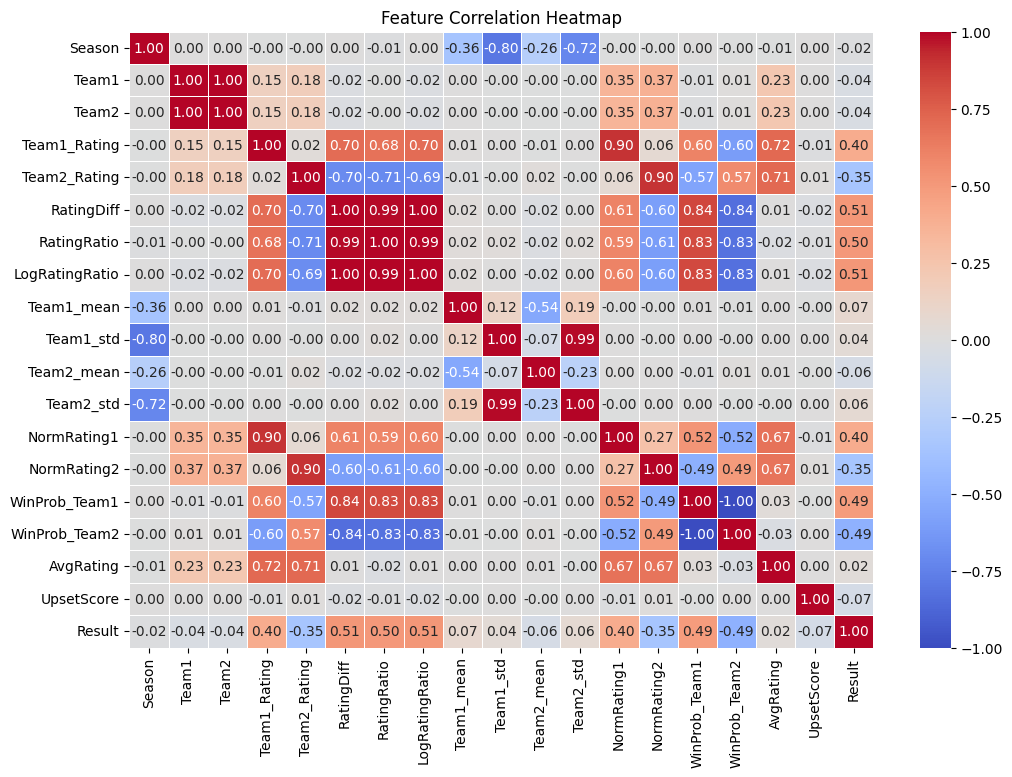

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

# Compute correlation matrix for features and actual results (excluding NaNs from 2024)
corr_matrix = submission_with_ratings.drop(columns=['ID', 'Pred']).corr()

# Plot correlation heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Feature Correlation Heatmap")
plt.show()


The correlation heatmap shows how each feature relates to the actual game outcomes (`Result`). Key observations:

* **RatingDiff** and **LogRatingRatio** have strong positive correlations with `Result`, meaning the higher the difference in ratings, the more likely Team1 is to win.
* **WinProb_Team1** also has a strong positive correlation with `Result`, confirming that the logistic transformation of RatingDiff is a meaningful predictor.
* **UpsetScore** is negatively correlated with `Result`, meaning higher values indicate a higher potential for an upset (as expected).
* **RatingRatio** has a moderate correlation with `Result`, though it is less linear than RatingDiff.

In [6]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

# Load your dataset (ensure you have the processed dataset)
# df = pd.read_csv("processed_dataset.csv")  # Replace with your actual file path
df = submission_with_ratings.copy()

# Select features and target variable
features = [
    'RatingDiff', 'RatingRatio', 'LogRatingRatio', 'NormRating1', 'NormRating2',
    'WinProb_Team1', 'WinProb_Team2', 'AvgRating', 'UpsetScore'
]

df_train = df.dropna(subset=['Result'])  # Exclude 2024 season

X = df_train[features]
y = df_train['Result']

# Split into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Create a pipeline with imputation and normalization
pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler()),
    ('model', RandomForestClassifier(n_estimators=100, random_state=42))
])

# Train the model
pipeline.fit(X_train, y_train)

# Get feature importances
feature_importances = pipeline.named_steps['model'].feature_importances_
importance_df = pd.DataFrame({'Feature': features, 'Importance': feature_importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Display feature importance
print(importance_df)


          Feature  Importance
1     RatingRatio    0.162496
0      RatingDiff    0.140887
2  LogRatingRatio    0.137383
3     NormRating1    0.122259
5   WinProb_Team1    0.117918
6   WinProb_Team2    0.107384
7       AvgRating    0.105872
4     NormRating2    0.104153
8      UpsetScore    0.001648


In [76]:
  import pandas as pd
import numpy as np
import os
from pathlib import Path
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Define paths
DEFAULT_COMPETITION_DATA_PATH = Path(os.path.abspath(os.path.join(os.getcwd(), r"data\kaggle")))
SUBMISSION_DATA_PATH = Path(os.path.abspath(os.path.join(os.getcwd(), r"data\submissions")))
DATA_PATH = Path(os.path.abspath(os.path.join(os.getcwd(), r"data\fivethirtyeight")))

# Load data files
sample_submission = pd.read_csv(DEFAULT_COMPETITION_DATA_PATH / "SampleSubmissionStage1.csv")
ratings_men = pd.read_csv(DATA_PATH / "538ratingsMen_2016-2023.csv")
ratings_women = pd.read_csv(DATA_PATH / "538ratingsWomen_2016-2023.csv")
results_men = pd.read_csv(DEFAULT_COMPETITION_DATA_PATH / "MNCAATourneyCompactResults.csv")
results_women = pd.read_csv(DEFAULT_COMPETITION_DATA_PATH / "WNCAATourneyCompactResults.csv")

# Parse Season, Team1, Team2 from ID in sample_submission
sample_submission[['Season', 'Team1', 'Team2']] = sample_submission['ID'].str.split('_', expand=True)
sample_submission['Season'] = sample_submission['Season'].astype(int)
sample_submission['Team1'] = sample_submission['Team1'].astype(int)
sample_submission['Team2'] = sample_submission['Team2'].astype(int)

# Prepare ratings data (2016-2023)
ratings_men = ratings_men[['Season', 'TeamID', '538rating']].rename(columns={'538rating': 'Rating'})
ratings_women = ratings_women[['Season', 'TeamID', '538rating']].rename(columns={'538rating': 'Rating'})

def add_inverted_matchups(results_df):
    results_df = results_df[['Season', 'WTeamID', 'LTeamID']].copy()
    results_df = results_df.rename(columns={'WTeamID': 'Team1', 'LTeamID': 'Team2'})
    results_df['Result'] = 1  # Team1 wins
    results_rev = results_df.rename(columns={'Team1': 'Team2', 'Team2': 'Team1'})
    results_rev['Result'] = 0  # Team1 loses
    combined_df = pd.concat([results_df, results_rev]).rename(columns={'WTeamID': 'Team1', 'LTeamID': 'Team2'})

    return combined_df

results_men = add_inverted_matchups(results_men)
results_women = add_inverted_matchups(results_women)

def merge_ratings(matchups_df, ratings_df):
    """Merge results with ratings and create features for training."""
    # Merge with ratings
    matchups_df = matchups_df.merge(ratings_df, left_on=['Season', 'Team1'], right_on=['Season', 'TeamID'], how='left') \
                           .rename(columns={'Rating': 'Team1_Rating'}).drop(columns=['TeamID'])
    matchups_df = matchups_df.merge(ratings_df, left_on=['Season', 'Team2'], right_on=['Season', 'TeamID'], how='left') \
                           .rename(columns={'Rating': 'Team2_Rating'}).drop(columns=['TeamID'])

    # Remove rows where either Team1_Rating or Team2_Rating is missing
    matchups_df = matchups_df.dropna(subset=['Team1_Rating', 'Team2_Rating'])

    # Compute features
    matchups_df['RatingDiff'] = matchups_df['Team1_Rating'] - matchups_df['Team2_Rating']
    matchups_df['RatingRatio'] = matchups_df['Team1_Rating'] / matchups_df['Team2_Rating']
    matchups_df['LogRatingRatio'] = np.log(matchups_df['Team1_Rating']) - np.log(matchups_df['Team2_Rating'])
    matchups_df['WinProb_Team1'] = 1 / (1 + np.exp(-matchups_df['RatingDiff']))
    matchups_df['WinProb_Team2'] = 1 - matchups_df['WinProb_Team1']
    matchups_df['AvgRating'] = (matchups_df['Team1_Rating'] + matchups_df['Team2_Rating']) / 2
    
    # Z-score normalization (by season)
    season_mean_std = matchups_df.groupby('Season')[['Team1_Rating', 'Team2_Rating']].agg(['mean', 'std'])
    season_mean_std.columns = ['Team1_mean', 'Team1_std', 'Team2_mean', 'Team2_std']
    matchups_df = matchups_df.merge(season_mean_std, on='Season', how='left')

    # Prevent division by zero
    matchups_df['Team1_std'] = matchups_df['Team1_std'].replace(0, 1e-6)
    matchups_df['Team2_std'] = matchups_df['Team2_std'].replace(0, 1e-6)

    matchups_df['NormRating1'] = (matchups_df['Team1_Rating'] - matchups_df['Team1_mean']) / matchups_df['Team1_std']
    matchups_df['NormRating2'] = (matchups_df['Team2_Rating'] - matchups_df['Team2_mean']) / matchups_df['Team2_std']

    return matchups_df

# Prepare men’s and women’s tournament training data
train_data_men = merge_ratings(results_men, ratings_men)
train_data_women = merge_ratings(results_women, ratings_women)

# Separate men's and women's sample submission data
sample_submission_men = sample_submission[sample_submission['Team1'] < 3000].copy()
sample_submission_women = sample_submission[sample_submission['Team1'] >= 3000].copy()

# Prepare test data from submission file
submission_with_ratings_men = merge_ratings(sample_submission_men, ratings_men)
submission_with_ratings_women = merge_ratings(sample_submission_women, ratings_women)

def train_and_predict(train_df, submission_df, selected_features):
    """Train a model on past seasons and return predictions."""
    predictions_list = []  # Store predictions as a DataFrame list
    """Train a model on past seasons and predict for upcoming matchups."""
    for season in range(2021, 2024):  # Predict for 2021-2023
        train_season_df = train_df[train_df['Season'] < season]
        test_season_df = submission_df[submission_df['Season'] == season].copy()
        
        if train_season_df.empty or train_season_df.shape[0] == 0:
            print(f"Skipping training for Season {season}: No sufficient training data available.")
            continue  # Skip if no training data exists (e.g., for 2021)

        if test_season_df.empty or test_season_df.shape[0] == 0:
            print(f"Skipping training for Season {season}: No sufficient testing data available.")
            continue  # Skip if no training data exists (e.g., for 2021)
      
        X_train, y_train = train_season_df[selected_features], train_season_df['Result']
        X_test = test_season_df[selected_features]

        # Train Logistic Regression Model
        pipeline = Pipeline([
            ('scaler', StandardScaler()),
            ('model', LogisticRegression(solver='liblinear', random_state=42))
        ])
        pipeline.fit(X_train, y_train)

        # Store predictions in a temporary DataFrame
        predictions = pd.DataFrame({
            'ID': test_season_df['ID'],
            'Pred': pipeline.predict_proba(X_test)[:, 1]
        })

        predictions_list.append(predictions)  # Store predictions in list
    
    return pd.concat(predictions_list) if predictions_list else pd.DataFrame()        

# Define selected features for training
selected_features = ['RatingRatio', 'RatingDiff', 'LogRatingRatio', 'WinProb_Team1', 'WinProb_Team2', 'AvgRating', 'NormRating1', 'NormRating2']

# Train and predict separately for men's and women's tournaments
predictions_men = train_and_predict(train_data_men, submission_with_ratings_men, selected_features)
predictions_women = train_and_predict(train_data_women, submission_with_ratings_women, selected_features)

# Concatenate predictions and update submission files
final_predictions = pd.concat([predictions_men, predictions_women]) if not predictions_men.empty and not predictions_women.empty else pd.DataFrame()
# final_submission = pd.concat([submission_with_ratings_men, submission_with_ratings_women])
if not final_predictions.empty and 'ID' in final_predictions.columns:
    sample_submission = sample_submission.merge(final_predictions[['ID', 'Pred']], on='ID', how='left', suffixes=('', '_pred'))
    sample_submission['Pred'] = sample_submission['Pred_pred'].fillna(sample_submission['Pred'])
    sample_submission.drop(columns=['Pred_pred'], inplace=True)
sample_submission[['ID', 'Pred']].to_csv(SUBMISSION_DATA_PATH / "Round1_538Ratings.csv", index=False)


In [69]:
final_predictions

,ID,Pred
0,2021_1101_1104,0.119607
1,2021_1101_1111,0.772212
2,2021_1101_1116,0.178421
3,2021_1101_1124,0.057591
4,2021_1101_1140,0.228811
...,...,...
6567,2023_3437_3450,0.551675
6568,2023_3437_3452,0.727188
6569,2023_3439_3450,0.797196
6570,2023_3439_3452,0.900809


In [75]:
sample_submission[sample_submission['ID'] == '2021_1101_1104']

,ID,Pred,Season,Team1,Team2
2,2021_1101_1104,0.119607,2021,1101,1104


In [74]:
if not final_predictions.empty and 'ID' in final_predictions.columns:
    sample_submission = sample_submission.merge(final_predictions[['ID', 'Pred']], on='ID', how='left', suffixes=('', '_pred'))
    sample_submission['Pred'] = sample_submission['Pred_pred'].fillna(sample_submission['Pred'])
    sample_submission.drop(columns=['Pred_pred'], inplace=True)


In [63]:
predictions_men

,ID,Pred
0,2021_1101_1104,0.119607
1,2021_1101_1111,0.772212
2,2021_1101_1116,0.178421
3,2021_1101_1124,0.057591
4,2021_1101_1140,0.228811
...,...,...
6829,2023_1436_1452,0.244068
6830,2023_1436_1462,0.238795
6831,2023_1438_1452,0.485827
6832,2023_1438_1462,0.478752
